In [2]:
!pip install ultralytics

In [3]:
!pip install roboflow

In [4]:
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import Image, display
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="BJ3guEfodhhb55LO86zY")
project = rf.workspace("product5k").project("grocery-ey3gm")
version = project.version(1)
dataset = version.download("yolov8")

# Save dataset path
dataset_path = dataset.location
print(f"Dataset downloaded to: {dataset_path}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to grocery-1 in yolov8:: 100%|██████████| 8878/8878 [00:00<00:00, 10611.09it/s]

Dataset downloaded to: /kaggle/working/grocery-1


In [6]:
data_yaml = os.path.join(dataset_path, "data.yaml")
!cat {data_yaml}

names:
- beans
- cake
- candy
- cereal
- chips
- chocolate
- coffee
- corn
- fish
- flour
- honey
- jam
- juice
- milk
- nuts
- oil
- pasta
- rice
- soda
- spices
- sugar
- tea
- tomato_sauce
- vinegar
- water
nc: 25
roboflow:
  license: CC BY 4.0
  project: grocery-ey3gm
  url: https://universe.roboflow.com/product5k/grocery-ey3gm/dataset/1
  version: 1
  workspace: product5k
test: ../test/images
train: ../train/images
val: ../valid/images


In [7]:
# Load a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data=data_yaml,
    epochs=25,
    batch=16,
    imgsz=416,
    workers=4,
    device=0,          # use GPU
    patience=None,       # early stopping
    save=True,
    project="grocery_detector",
    name="yolov8n_grocery_v1",
    exist_ok=True
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/grocery-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_grocery_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [9]:
# Load the best model
best_model = YOLO("/kaggle/working/runs/detect/grocery_detector/yolov8n_grocery_v1/weights/best.pt")

# Run validation
val_results = best_model.val(data=data_yaml, split="val")
print(f"Validation mAP50: {val_results.box.map50:.4f}")
print(f"Validation mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 663.6±232.1 MB/s, size: 21.0 KB)
val: Scanning /kaggle/working/grocery-1/valid/labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 308.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 9.1it/s 6.2s<0.1s
                   all        883       2025      0.801      0.776      0.849      0.713
                 beans         19         38      0.726      0.906      0.867      0.733
                  cake         33         57      0.876      0.864      0.928      0.825
                 candy         69        119       0.83      0.658      0.805      0.607
                cereal         64        107      0.805      0.886      0.906      0.766
                 chips         30  

In [10]:
test_images_dir = os.path.join(dataset_path, "test", "images")
output_dir = "inference_results"

# Run prediction
best_model.predict(
    source=test_images_dir,
    conf=0.25,          # confidence threshold
    iou=0.45,           # NMS IoU
    save=True,
    project=output_dir,
    name="test_preds"
)

print(f"Predictions saved to: {output_dir}/test_preds")


image 1/445 /kaggle/working/grocery-1/test/images/BEANS0012_png.rf.229ae741be8dcb706500fdf0af7ff2c7.jpg: 416x416 3 beanss, 2 tomato_sauces, 6.8ms
image 2/445 /kaggle/working/grocery-1/test/images/BEANS0025_png.rf.0db20783737203f299ffa568d26e4459.jpg: 416x416 1 nuts, 6.2ms
image 3/445 /kaggle/working/grocery-1/test/images/BEANS0035_png.rf.52ad90a67d3e59fbaffa6615952cf9c2.jpg: 416x416 3 beanss, 6.3ms
image 4/445 /kaggle/working/grocery-1/test/images/BEANS0057_png.rf.defe1a78611b4a2c75bbb97d28c57350.jpg: 416x416 2 beanss, 1 chips, 6.0ms
image 5/445 /kaggle/working/grocery-1/test/images/BEANS0058_png.rf.a1bd856524f7f1b4b3fd0aaa11a1c285.jpg: 416x416 2 beanss, 1 fish, 6.0ms
image 6/445 /kaggle/working/grocery-1/test/images/BEANS0065_png.rf.104bb8e2804e102a76d7fd2adc1f7ce5.jpg: 416x416 2 beanss, 1 nuts, 6.2ms
image 7/445 /kaggle/working/grocery-1/test/images/BEANS0066_png.rf.44fc91153f638ab0293c3e4499e765dc.jpg: 416x416 2 beanss, 6.0ms
image 8/445 /kaggle/working/grocery-1/test/images/BEANS0

Found 445 predicted images.


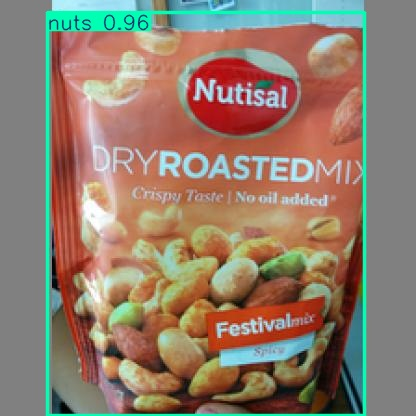


--------------------------------------------------



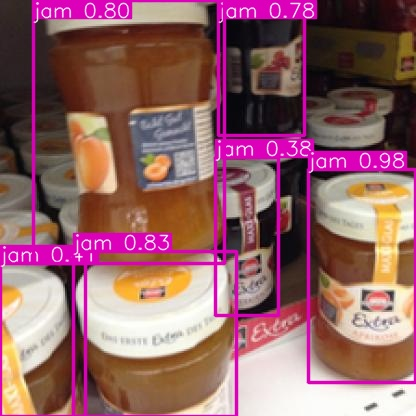


--------------------------------------------------



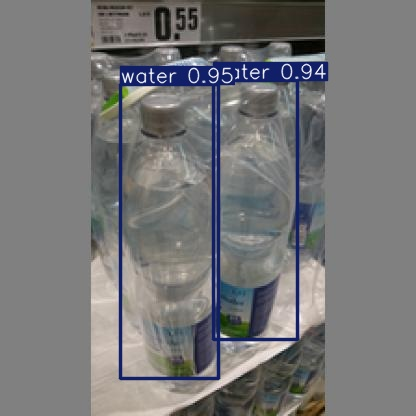


--------------------------------------------------



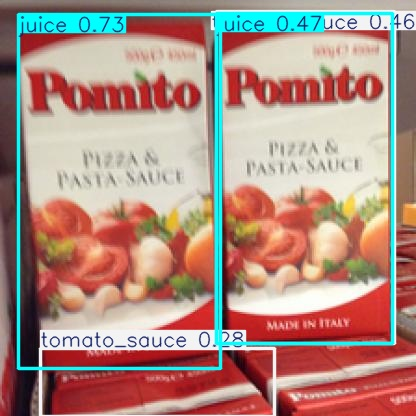


--------------------------------------------------



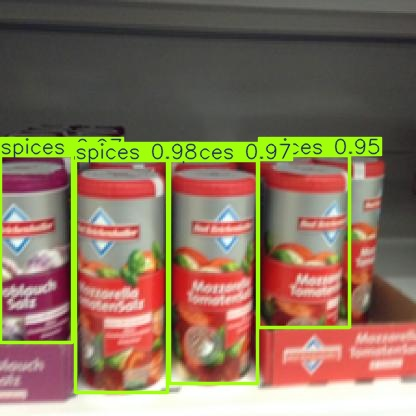


--------------------------------------------------



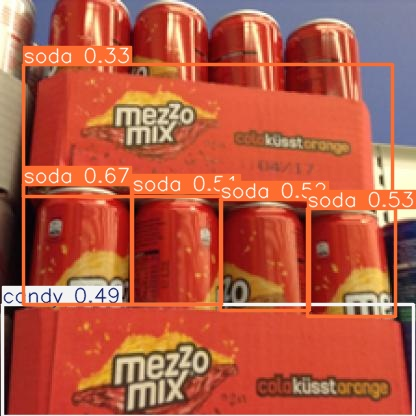


--------------------------------------------------



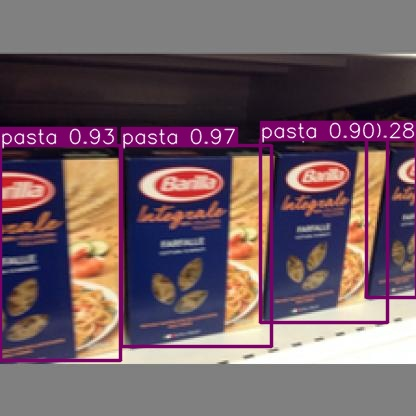


--------------------------------------------------



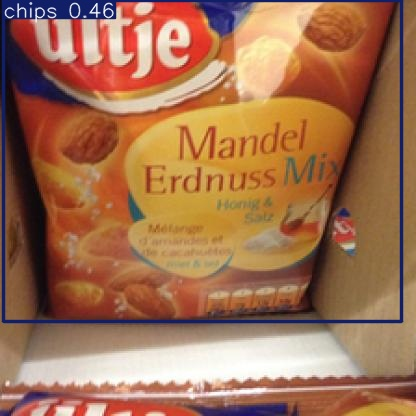


--------------------------------------------------



In [50]:
import glob
from IPython.display import Image, display

# Correct path to your predicted images
pred_images = glob.glob("/kaggle/working/runs/detect/inference_results/test_preds/*.jpg")

print(f"Found {len(pred_images)} predicted images.")

for img_path in pred_images[:8]:   # show first 8 images
    display(Image(filename=img_path))
    print("\n" + "-"*50 + "\n")

In [51]:
sample_image = glob.glob(os.path.join(test_images_dir, "*.jpg"))[0]
results = best_model(sample_image, conf=0.25)

# Print detections
for r in results:
    boxes = r.boxes
    for box in boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = best_model.names[cls]
        print(f"Detected: {class_name} (confidence: {conf:.2f})")


image 1/1 /kaggle/working/grocery-1/test/images/NUTS0161_png.rf.c186769847db44e43984d2312f1fbb00.jpg: 416x416 1 nuts, 10.7ms
Speed: 1.8ms preprocess, 10.7ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 416)
Detected: nuts (confidence: 0.96)


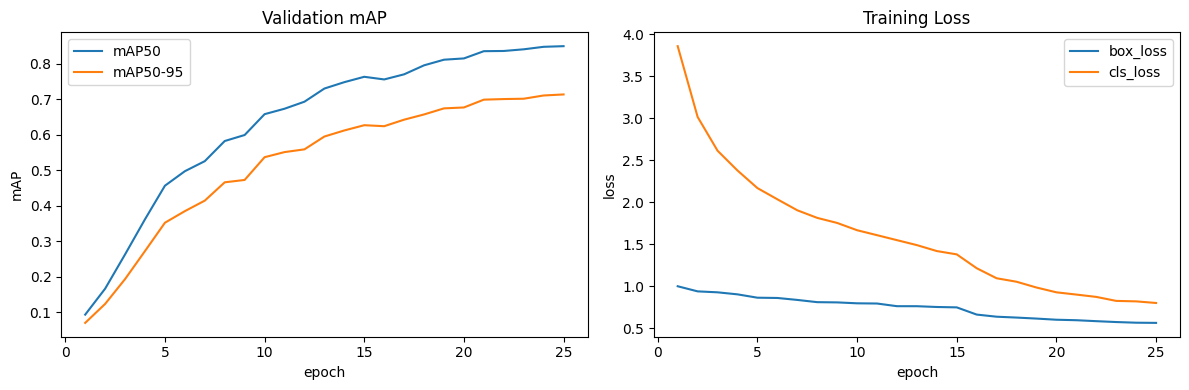

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/kaggle/working/runs/detect/grocery_detector/yolov8n_grocery_v1/results.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    # Plot mAP50 and loss
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
    plt.xlabel('epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.title('Validation mAP')
    
    plt.subplot(1,2,2)
    plt.plot(df['epoch'], df['train/box_loss'], label='box_loss')
    plt.plot(df['epoch'], df['train/cls_loss'], label='cls_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.title('Training Loss')
    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found yet.")


image 1/1 /kaggle/working/grocery-1/test/images/CAKE0025_png.rf.a9b0b72debdceacdaa93e246741473d4.jpg: 416x416 2 cakes, 7.2ms
Speed: 0.8ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)


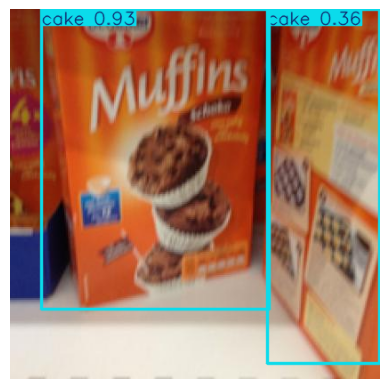

In [53]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("runs/detect/grocery_detector/yolov8n_grocery_v1/weights/best.pt")
results = model("/kaggle/working/grocery-1/test/images/CAKE0025_png.rf.a9b0b72debdceacdaa93e246741473d4.jpg")[0]
plt.imshow(cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


image 1/1 /kaggle/working/grocery-1/test/images/RICE0104_png.rf.01f230d0b86b45d7d180e1c7e5fabf53.jpg: 416x416 2 rices, 6.8ms
Speed: 0.8ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)


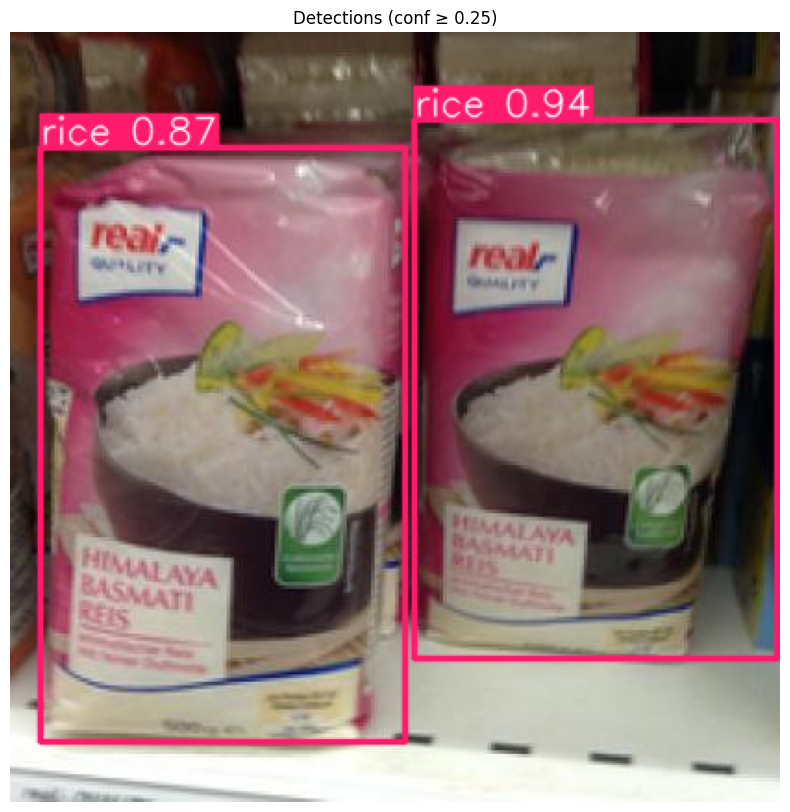


Detected objects:
  - rice: 0.94
  - rice: 0.87


In [58]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

detect_and_show("/kaggle/working/grocery-1/test/images/RICE0104_png.rf.01f230d0b86b45d7d180e1c7e5fabf53.jpg")
def detect_and_show(image_path, model_path="runs/detect/grocery_detector/yolov8n_grocery_v1/weights/best.pt", conf_threshold=0.25):
    """
    Run detection on an image and display results with bounding boxes and confidence scores.
    
    Args:
        image_path (str): Path to input image
        model_path (str): Path to trained YOLO best.pt file
        conf_threshold (float): Confidence threshold for detections
    """
    # Load model
    model = YOLO(model_path)
    
    # Run inference
    results = model(image_path, conf=conf_threshold)[0]
    
    # Get annotated image (bounding boxes + labels)
    annotated_img = results.plot()  # returns numpy array (BGR)
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Display using matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Detections (conf ≥ {conf_threshold})")
    plt.show()
    
    # Print detection details
    if results.boxes is not None:
        print("\nDetected objects:")
        for box in results.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            name = model.names[cls]
            print(f"  - {name}: {conf:.2f}")
    else:
        print("No objects detected.")